In [3]:
import os

print(os.getcwd())

/Users/abhilashanegi/NIC_Forecasting


In [4]:
os.listdir()

['forecasting.ipynb', 'forecast.ipynb', '.ipynb_checkpoints']

In [6]:
import pandas as pd

df = pd.read_csv("/Users/abhilashanegi/Downloads/top_states_monthly.csv")
df.head()

,month_start,state,applications
0,2025-07-01,ANDHRA PRADESH,6
1,2025-08-01,ANDHRA PRADESH,1158
2,2025-09-01,ANDHRA PRADESH,3
3,2025-10-01,ANDHRA PRADESH,34026
4,2026-01-01,ANDHRA PRADESH,6


In [7]:
df.groupby('state').agg(
    months=('month_start','count'),
    total_apps=('applications','sum')
).sort_values('total_apps', ascending=False)

,months,total_apps
state,,
ANDHRA PRADESH,8,292152
MAHARASHTRA,34,274587
KARNATAKA,27,188478
KERALA,14,171900
UTTAR PRADESH,29,168501
MADHYA PRADESH,14,120123
TAMIL NADU,20,112674
BIHAR,9,96333
PUNJAB,23,94224


In [8]:
mh = df[df['state'] == 'MAHARASHTRA'].copy()

print(mh.shape)

mh.head()

(34, 3)


,month_start,state,applications
72,2023-08-01,MAHARASHTRA,9
73,2023-09-01,MAHARASHTRA,21
74,2023-10-01,MAHARASHTRA,9
75,2023-11-01,MAHARASHTRA,12
76,2023-12-01,MAHARASHTRA,30


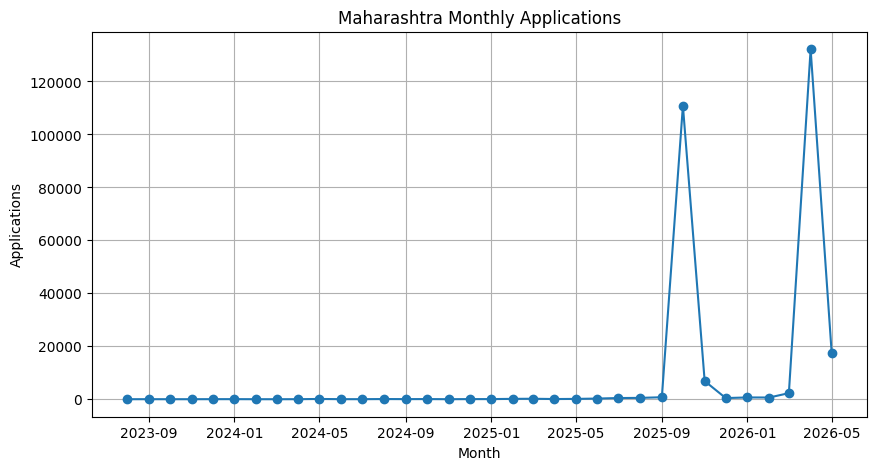

In [9]:
import matplotlib.pyplot as plt

mh['month_start'] = pd.to_datetime(mh['month_start'])

plt.figure(figsize=(10,5))
plt.plot(mh['month_start'], mh['applications'], marker='o')
plt.title('Maharashtra Monthly Applications')
plt.xlabel('Month')
plt.ylabel('Applications')
plt.grid(True)

plt.show()

In [10]:
state_share = (
    df.groupby('state')['applications']
      .sum()
      .reset_index()
)

total_apps = state_share['applications'].sum()

state_share['share_pct'] = (
    state_share['applications'] / total_apps * 100
)

state_share = state_share.sort_values(
    'applications',
    ascending=False
)

state_share.head(10)

,state,applications,share_pct
0,ANDHRA PRADESH,292152,18.141546
5,MAHARASHTRA,274587,17.050825
2,KARNATAKA,188478,11.703778
3,KERALA,171900,10.674347
9,UTTAR PRADESH,168501,10.463282
4,MADHYA PRADESH,120123,7.459189
8,TAMIL NADU,112674,6.996634
1,BIHAR,96333,5.981919
7,PUNJAB,94224,5.850958
6,ODISHA,91431,5.677523


In [11]:
june_forecast = 371411

state_share['forecast_june_2026'] = (
    june_forecast * state_share['share_pct'] / 100
)

state_share[['state','share_pct','forecast_june_2026']].head(10)

,state,share_pct,forecast_june_2026
0,ANDHRA PRADESH,18.141546,67379.697176
5,MAHARASHTRA,17.050825,63328.640258
2,KARNATAKA,11.703778,43469.120747
3,KERALA,10.674347,39645.697940
9,UTTAR PRADESH,10.463282,38861.778642
4,MADHYA PRADESH,7.459189,27704.247665
8,TAMIL NADU,6.996634,25986.267421
1,BIHAR,5.981919,22217.504477
7,PUNJAB,5.850958,21731.100888
6,ODISHA,5.677523,21086.944784


In [12]:
state_share[['state','forecast_june_2026']].to_csv(
    "top_states_forecast.csv",
    index=False
)

print("saved")

saved


In [14]:
june = 371410.7986132679
july = 352139.3425300732

pct_change = ((july-june)/june)*100
print(round(pct_change,2))

-5.19


In [16]:
import pandas as pd

forecast_df = pd.DataFrame({
    'month_start': [
        '2026-06-01',
        '2026-07-01',
        '2026-08-01',
        '2026-09-01',
        '2026-10-01',
        '2026-11-01'
    ],
    'forecast_applications': [
        371410.7986132679,
        352139.3425300732,
        342404.04783489153,
        337390.12961442844,
        334781.4834695042,
        333416.9896972891
    ]
})

forecast_df

,month_start,forecast_applications
0,2026-06-01,371410.798613
1,2026-07-01,352139.342530
2,2026-08-01,342404.047835
3,2026-09-01,337390.129614
4,2026-10-01,334781.483470
5,2026-11-01,333416.989697


In [17]:
state_share = pd.DataFrame({
    'state': [
        'ANDHRA PRADESH',
        'MAHARASHTRA',
        'KARNATAKA',
        'KERALA',
        'UTTAR PRADESH',
        'MADHYA PRADESH',
        'TAMIL NADU',
        'BIHAR',
        'PUNJAB',
        'ODISHA'
    ],
    'share_pct': [
        18.141546,
        17.050825,
        11.703778,
        10.674347,
        10.463282,
        7.459189,
        6.996634,
        5.981919,
        5.850958,
        5.677523
    ]
})

state_share.head()

,state,share_pct
0,ANDHRA PRADESH,18.141546
1,MAHARASHTRA,17.050825
2,KARNATAKA,11.703778
3,KERALA,10.674347
4,UTTAR PRADESH,10.463282


In [18]:
heatmap_df = forecast_df.assign(key=1).merge(
    state_share.assign(key=1),
    on='key'
).drop('key', axis=1)

heatmap_df['forecast_applications'] = (
    heatmap_df['forecast_applications']
    * heatmap_df['share_pct'] / 100
)

heatmap_df = heatmap_df[[
    'month_start',
    'state',
    'forecast_applications'
]]

heatmap_df.head(20)

,month_start,state,forecast_applications
0,2026-06-01,ANDHRA PRADESH,67379.660879
1,2026-06-01,MAHARASHTRA,63328.605303
2,2026-06-01,KARNATAKA,43469.095338
3,2026-06-01,KERALA,39645.677439
4,2026-06-01,UTTAR PRADESH,38861.759237
5,2026-06-01,MADHYA PRADESH,27704.233435
6,2026-06-01,TAMIL NADU,25986.254215
7,2026-06-01,BIHAR,22217.493130
8,2026-06-01,PUNJAB,21731.089834
9,2026-06-01,ODISHA,21086.933516


In [19]:
heatmap_df.to_csv(
    "/Users/abhilashanegi/Downloads/forecast_heatmap.csv",
    index=False
)

In [20]:
import pandas as pd

monthly = pd.read_sql("""
SELECT month,
       applications
FROM report_monthly_trend
ORDER BY month
""", conn)

monthly.head()

NameError: name 'conn' is not defined

In [21]:
print(df.shape)

df.head()

df.columns

(190, 3)


Index(['month_start', 'state', 'applications'], dtype='str')

In [22]:
print(df.shape)

df.groupby("state").size().sort_values(ascending=False).head(10)

(190, 3)


state
MAHARASHTRA       34
UTTAR PRADESH     29
KARNATAKA         27
PUNJAB            23
TAMIL NADU        20
KERALA            14
MADHYA PRADESH    14
ODISHA            12
BIHAR              9
ANDHRA PRADESH     8
dtype: int64

In [23]:
df.head(20)

,month_start,state,applications
0,2025-07-01,ANDHRA PRADESH,6
1,2025-08-01,ANDHRA PRADESH,1158
2,2025-09-01,ANDHRA PRADESH,3
3,2025-10-01,ANDHRA PRADESH,34026
4,2026-01-01,ANDHRA PRADESH,6
5,2026-03-01,ANDHRA PRADESH,9
6,2026-04-01,ANDHRA PRADESH,220275
7,2026-05-01,ANDHRA PRADESH,36669
8,2025-08-01,BIHAR,6054
9,2025-10-01,BIHAR,4284


In [24]:
import os
print(os.getcwd())
os.listdir()

/Users/abhilashanegi/NIC_Forecasting


['forecast_change_kpi.csv',
 'forecasting.ipynb',
 'top_states_forecast.csv',
 'forecast.ipynb',
 '.ipynb_checkpoints']

In [25]:
import pandas as pd

df = pd.read_csv("/Users/abhilashanegi/Downloads/top_states_monthly.csv")

print(df.shape)
df.head()

(190, 3)


,month_start,state,applications
0,2025-07-01,ANDHRA PRADESH,6
1,2025-08-01,ANDHRA PRADESH,1158
2,2025-09-01,ANDHRA PRADESH,3
3,2025-10-01,ANDHRA PRADESH,34026
4,2026-01-01,ANDHRA PRADESH,6


In [26]:
df["month_start"] = pd.to_datetime(df["month_start"])

monthly_total = (
    df.groupby("month_start")["applications"]
      .sum()
      .reset_index()
      .sort_values("month_start")
)

monthly_total.head()

,month_start,applications
0,2023-08-01,9
1,2023-09-01,24
2,2023-10-01,9
3,2023-11-01,12
4,2023-12-01,42


In [27]:
print(monthly_total.shape)
monthly_total.tail()

(34, 2)


,month_start,applications
29,2026-01-01,7179
30,2026-02-01,10953
31,2026-03-01,14538
32,2026-04-01,749133
33,2026-05-01,185292


In [28]:
train = monthly_total.iloc[:-6]
test = monthly_total.iloc[-6:]

print("Train rows:", len(train))
print("Test rows:", len(test))

train.tail()

Train rows: 28
Test rows: 6


,month_start,applications
23,2025-07-01,3444
24,2025-08-01,29022
25,2025-09-01,21519
26,2025-10-01,546246
27,2025-11-01,33909


In [29]:
test

,month_start,applications
28,2025-12-01,4434
29,2026-01-01,7179
30,2026-02-01,10953
31,2026-03-01,14538
32,2026-04-01,749133
33,2026-05-01,185292


In [30]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train["applications"], order=(1,1,1))

model_fit = model.fit()

predictions = model_fit.forecast(steps=len(test))

predictions

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


28    545345.692794
29     33946.959536
30    545307.736075
31     33984.913437
32    545269.784991
33     34022.861704
Name: predicted_mean, dtype: float64

In [31]:
comparison_df = test.copy()

comparison_df["forecast"] = predictions.values

comparison_df

,month_start,applications,forecast
28,2025-12-01,4434,545345.692794
29,2026-01-01,7179,33946.959536
30,2026-02-01,10953,545307.736075
31,2026-03-01,14538,33984.913437
32,2026-04-01,749133,545269.784991
33,2026-05-01,185292,34022.861704


In [32]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

mae = mean_absolute_error(
    comparison_df["applications"],
    comparison_df["forecast"]
)

rmse = np.sqrt(
    mean_squared_error(
        comparison_df["applications"],
        comparison_df["forecast"]
    )
)

mape = np.mean(
    np.abs(
        (comparison_df["applications"] -
         comparison_df["forecast"])
        /
        comparison_df["applications"]
    )
) * 100

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 246102.2758576772
RMSE: 327530.5868926561
MAPE: 2948.8797955713158


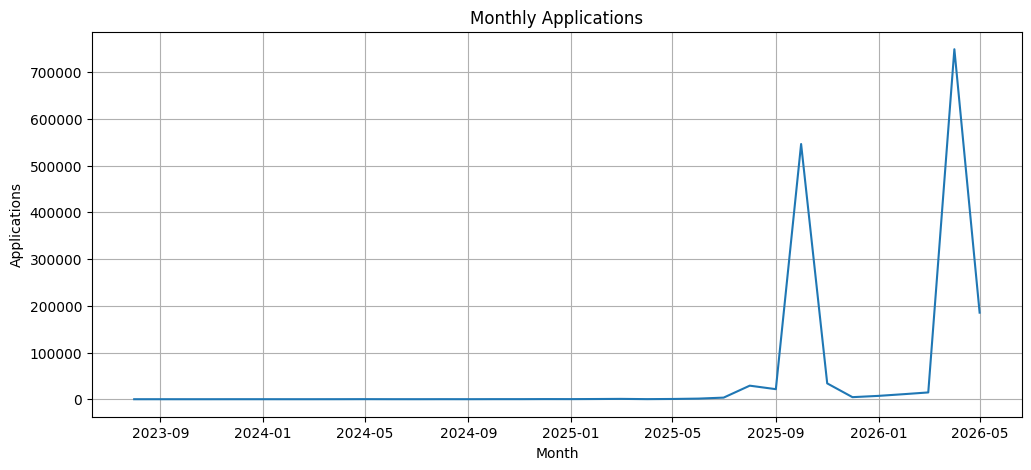

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(monthly_total["month_start"],
         monthly_total["applications"])

plt.title("Monthly Applications")
plt.xlabel("Month")
plt.ylabel("Applications")
plt.grid(True)

plt.show()

In [34]:
import numpy as np

monthly_total["log_apps"] = np.log1p(monthly_total["applications"])

monthly_total.head()

,month_start,applications,log_apps
0,2023-08-01,9,2.302585
1,2023-09-01,24,3.218876
2,2023-10-01,9,2.302585
3,2023-11-01,12,2.564949
4,2023-12-01,42,3.761200


In [35]:
train_log = monthly_total.iloc[:-6]
test_log = monthly_total.iloc[-6:]

from statsmodels.tsa.arima.model import ARIMA

model_log = ARIMA(
    train_log["log_apps"],
    order=(1,1,1)
)

model_fit_log = model_log.fit()

pred_log = model_fit_log.forecast(
    steps=len(test_log)
)

forecast_original = np.expm1(pred_log)

comparison_log = test.copy()

comparison_log["forecast"] = forecast_original.values

comparison_log

,month_start,applications,forecast
28,2025-12-01,4434,145101.990961
29,2026-01-01,7179,50611.921777
30,2026-02-01,10953,108556.705363
31,2026-03-01,14538,62453.016267
32,2026-04-01,749133,93220.081015
33,2026-05-01,185292,69739.303177


In [36]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly_total["applications"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: 2.8231296531915695
p-value: 1.0


In [37]:
monthly_total["diff1"] = monthly_total["applications"].diff()

monthly_total[["month_start","applications","diff1"]].tail()

,month_start,applications,diff1
29,2026-01-01,7179,2745.0
30,2026-02-01,10953,3774.0
31,2026-03-01,14538,3585.0
32,2026-04-01,749133,734595.0
33,2026-05-01,185292,-563841.0


In [38]:
from statsmodels.tsa.stattools import adfuller

result_diff = adfuller(
    monthly_total["diff1"].dropna()
)

print("ADF Statistic:", result_diff[0])
print("p-value:", result_diff[1])

ADF Statistic: 3.9701485868869453
p-value: 1.0


In [39]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [40]:
sarima_model = SARIMAX(
    train["applications"],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_fit = sarima_model.fit()

sarima_pred = sarima_fit.forecast(
    steps=len(test)
)

sarima_pred

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


28    545466.909773
29     34014.730627
30    545608.175791
31     34537.856068
32    545339.021130
33     34367.767002
Name: predicted_mean, dtype: float64

In [41]:
print(df.shape)

df["month_start"].min()

df["month_start"].max()

(190, 3)


Timestamp('2026-05-01 00:00:00')

In [42]:
df["state"].nunique()

10

In [43]:
forecast_obj = model_fit.get_forecast(steps=6)

conf_int = forecast_obj.conf_int(alpha=0.10)

conf_int

,lower applications,upper applications
28,453974.212072,636717.173515
29,-57560.693253,125454.612325
30,415997.154823,674618.317327
31,-95422.170908,163391.997782
32,386863.351867,703676.218116
33,-124462.560995,192508.284402


In [44]:
conf_int["lower applications"] = (
    conf_int["lower applications"]
    .clip(lower=0)
)

conf_int

,lower applications,upper applications
28,453974.212072,636717.173515
29,0.000000,125454.612325
30,415997.154823,674618.317327
31,0.000000,163391.997782
32,386863.351867,703676.218116
33,0.000000,192508.284402


In [45]:
forecast_ci = pd.DataFrame({
    "month_start": test["month_start"].values,
    "forecast": predictions.values,
    "lower_bound": conf_int.iloc[:,0].values,
    "upper_bound": conf_int.iloc[:,1].values
})

forecast_ci["lower_bound"] = (
    forecast_ci["lower_bound"]
    .clip(lower=0)
)

forecast_ci

,month_start,forecast,lower_bound,upper_bound
0,2025-12-01,545345.692794,453974.212072,636717.173515
1,2026-01-01,33946.959536,0.000000,125454.612325
2,2026-02-01,545307.736075,415997.154823,674618.317327
3,2026-03-01,33984.913437,0.000000,163391.997782
4,2026-04-01,545269.784991,386863.351867,703676.218116
5,2026-05-01,34022.861704,0.000000,192508.284402


In [46]:
forecast_ci.to_csv(
    "forecast_confidence_intervals.csv",
    index=False
)

forecast_ci.head()

,month_start,forecast,lower_bound,upper_bound
0,2025-12-01,545345.692794,453974.212072,636717.173515
1,2026-01-01,33946.959536,0.000000,125454.612325
2,2026-02-01,545307.736075,415997.154823,674618.317327
3,2026-03-01,33984.913437,0.000000,163391.997782
4,2026-04-01,545269.784991,386863.351867,703676.218116


In [47]:
import os

os.listdir()

['forecast_change_kpi.csv',
 'forecasting.ipynb',
 'top_states_forecast.csv',
 'forecast_confidence_intervals.csv',
 'forecast.ipynb',
 '.ipynb_checkpoints']

In [48]:
train["month_start"].min()

Timestamp('2023-08-01 00:00:00')

In [49]:
train["month_start"].max()

Timestamp('2025-11-01 00:00:00')

In [50]:
df.head()

,month_start,state,applications
0,2025-07-01,ANDHRA PRADESH,6
1,2025-08-01,ANDHRA PRADESH,1158
2,2025-09-01,ANDHRA PRADESH,3
3,2025-10-01,ANDHRA PRADESH,34026
4,2026-01-01,ANDHRA PRADESH,6


In [51]:
print(df.shape)

print(df.columns)

df.head()

(190, 3)
Index(['month_start', 'state', 'applications'], dtype='str')


,month_start,state,applications
0,2025-07-01,ANDHRA PRADESH,6
1,2025-08-01,ANDHRA PRADESH,1158
2,2025-09-01,ANDHRA PRADESH,3
3,2025-10-01,ANDHRA PRADESH,34026
4,2026-01-01,ANDHRA PRADESH,6


In [52]:
df["month_start"] = pd.to_datetime(df["month_start"])

print(df.dtypes)

month_start     datetime64[us]
state                      str
applications             int64
dtype: object


In [53]:
df["year"] = df["month_start"].dt.year
df["month"] = df["month_start"].dt.month
df["quarter"] = df["month_start"].dt.quarter

df.head()

,month_start,state,applications,year,month,quarter
0,2025-07-01,ANDHRA PRADESH,6,2025,7,3
1,2025-08-01,ANDHRA PRADESH,1158,2025,8,3
2,2025-09-01,ANDHRA PRADESH,3,2025,9,3
3,2025-10-01,ANDHRA PRADESH,34026,2025,10,4
4,2026-01-01,ANDHRA PRADESH,6,2026,1,1


In [54]:
df = df.sort_values(
    ["state", "month_start"]
).reset_index(drop=True)

In [55]:
df["lag_1"] = df.groupby("state")["applications"].shift(1)

df["lag_3"] = df.groupby("state")["applications"].shift(3)

df["lag_6"] = df.groupby("state")["applications"].shift(6)

In [56]:
df["rolling_mean_3"] = (
    df.groupby("state")["applications"]
      .transform(lambda x: x.shift(1).rolling(3).mean())
)

df["rolling_mean_6"] = (
    df.groupby("state")["applications"]
      .transform(lambda x: x.shift(1).rolling(6).mean())
)

In [57]:
df.head(15)

,month_start,state,applications,year,month,quarter,lag_1,lag_3,lag_6,rolling_mean_3,rolling_mean_6
0,2025-07-01,ANDHRA PRADESH,6,2025,7,3,NaN,NaN,NaN,NaN,NaN
1,2025-08-01,ANDHRA PRADESH,1158,2025,8,3,6.0,NaN,NaN,NaN,NaN
2,2025-09-01,ANDHRA PRADESH,3,2025,9,3,1158.0,NaN,NaN,NaN,NaN
3,2025-10-01,ANDHRA PRADESH,34026,2025,10,4,3.0,6.0,NaN,389.0,NaN
4,2026-01-01,ANDHRA PRADESH,6,2026,1,1,34026.0,1158.0,NaN,11729.0,NaN
5,2026-03-01,ANDHRA PRADESH,9,2026,3,1,6.0,3.0,NaN,11345.0,NaN
6,2026-04-01,ANDHRA PRADESH,220275,2026,4,2,9.0,34026.0,6.0,11347.0,5868.0
7,2026-05-01,ANDHRA PRADESH,36669,2026,5,2,220275.0,6.0,1158.0,73430.0,42579.5
8,2025-08-01,BIHAR,6054,2025,8,3,NaN,NaN,NaN,NaN,NaN
9,2025-10-01,BIHAR,4284,2025,10,4,6054.0,NaN,NaN,NaN,NaN


In [58]:
df = df.dropna()

print(df.shape)

(130, 11)


In [59]:
print(df.shape)
df.head()

(130, 11)


,month_start,state,applications,year,month,quarter,lag_1,lag_3,lag_6,rolling_mean_3,rolling_mean_6
6,2026-04-01,ANDHRA PRADESH,220275,2026,4,2,9.0,34026.0,6.0,11347.0,5868.0
7,2026-05-01,ANDHRA PRADESH,36669,2026,5,2,220275.0,6.0,1158.0,73430.0,42579.5
14,2026-03-01,BIHAR,2814,2026,3,1,2004.0,132.0,6054.0,1254.0,2437.5
15,2026-04-01,BIHAR,58875,2026,4,2,2814.0,1626.0,4284.0,2148.0,1897.5
16,2026-05-01,BIHAR,20019,2026,5,2,58875.0,2004.0,525.0,21231.0,10996.0


In [60]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["state_encoded"] = le.fit_transform(df["state"])

df.head()

,month_start,state,applications,year,month,quarter,lag_1,lag_3,lag_6,rolling_mean_3,rolling_mean_6,state_encoded
6,2026-04-01,ANDHRA PRADESH,220275,2026,4,2,9.0,34026.0,6.0,11347.0,5868.0,0
7,2026-05-01,ANDHRA PRADESH,36669,2026,5,2,220275.0,6.0,1158.0,73430.0,42579.5,0
14,2026-03-01,BIHAR,2814,2026,3,1,2004.0,132.0,6054.0,1254.0,2437.5,1
15,2026-04-01,BIHAR,58875,2026,4,2,2814.0,1626.0,4284.0,2148.0,1897.5,1
16,2026-05-01,BIHAR,20019,2026,5,2,58875.0,2004.0,525.0,21231.0,10996.0,1


In [61]:
features = [
    "year",
    "month",
    "quarter",
    "lag_1",
    "lag_3",
    "lag_6",
    "rolling_mean_3",
    "rolling_mean_6",
    "state_encoded"
]

X = df[features]

y = df["applications"]

print(X.shape)
print(y.shape)

(130, 9)
(130,)


In [62]:
split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (104, 9)
Test : (26, 9)


In [64]:
!pip install lightgbm

zsh:1: command not found: pip


In [65]:
import lightgbm as lgb

print(lgb.__version__)

OSError: dlopen(/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/lightgbm/lib/lib_lightgbm.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib
  Referenced from: <D44045CD-B874-3A27-9A61-F131D99AACE4> /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/lightgbm/lib/lib_lightgbm.dylib
  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/local/lib/libomp/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/local/lib/libomp/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/local/lib/libomp/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/local/lib/libomp/libomp.dylib' (no such file)

In [1]:
import lightgbm as lgb

print(lgb.__version__)

OSError: dlopen(/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/lightgbm/lib/lib_lightgbm.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib
  Referenced from: <D44045CD-B874-3A27-9A61-F131D99AACE4> /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/lightgbm/lib/lib_lightgbm.dylib
  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/local/lib/libomp/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/local/lib/libomp/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/local/lib/libomp/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/local/lib/libomp/libomp.dylib' (no such file)

In [2]:
import sys

print(sys.executable)
print(sys.version)

/Library/Frameworks/Python.framework/Versions/3.13/bin/python3.13
3.13.7 (v3.13.7:bcee1c32211, Aug 14 2025, 19:10:51) [Clang 16.0.0 (clang-1600.0.26.6)]


In [3]:
import xgboost as xgb

print(xgb.__version__)


ModuleNotFoundError: No module named 'xgboost'

In [1]:
import xgboost as xgb

print(xgb.__version__)

XGBoostError: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <4E82201A-ED82-3451-AD25-7886C77941A1> /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file)"]


In [1]:
import xgboost as xgb

print(xgb.__version__)

3.3.0


In [2]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

NameError: name 'X_train' is not defined

In [3]:
%whos

Variable       Type            Data/Info
----------------------------------------
XGBRegressor   type            <class 'xgboost.sklearn.XGBRegressor'>
model          XGBRegressor    XGBRegressor(base_score=N<...>_parallel_tree=None, ...)
xgb            module          <module 'xgboost' from '/<...>ges/xgboost/__init__.py'>


In [4]:
df.head()

NameError: name 'df' is not defined

In [5]:
import pandas as pd

df = pd.read_csv("/Users/abhilashanegi/Downloads/top_states_monthly.csv")

In [6]:
df["month_start"] = pd.to_datetime(df["month_start"])

df["year"] = df["month_start"].dt.year
df["month"] = df["month_start"].dt.month
df["quarter"] = df["month_start"].dt.quarter

df = df.sort_values(
    ["state", "month_start"]
).reset_index(drop=True)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["state_encoded"] = le.fit_transform(df["state"])

df["lag_1"] = df.groupby("state")["applications"].shift(1)
df["lag_3"] = df.groupby("state")["applications"].shift(3)
df["lag_6"] = df.groupby("state")["applications"].shift(6)

df["rolling_mean_3"] = (
    df.groupby("state")["applications"]
      .transform(lambda x: x.shift(1).rolling(3).mean())
)

df["rolling_mean_6"] = (
    df.groupby("state")["applications"]
      .transform(lambda x: x.shift(1).rolling(6).mean())
)

df = df.dropna()

In [7]:
features = [
    "year",
    "month",
    "quarter",
    "lag_1",
    "lag_3",
    "lag_6",
    "rolling_mean_3",
    "rolling_mean_6",
    "state_encoded"
]

X = df[features]
y = df["applications"]

split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

print(X_train.shape)
print(X_test.shape)

(104, 9)
(26, 9)


In [8]:
model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [9]:
preds = model.predict(X_test)

preds[:10]

array([  350.93542, 28820.637  ,  7750.61   ,  -235.14409,  -225.39795,
        -279.0489 ,  4629.614  , -2910.06   , -2332.6433 ,  -332.49197],
      dtype=float32)

In [10]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

mae = mean_absolute_error(y_test, preds)

rmse = mean_squared_error(
    y_test,
    preds
) ** 0.5

mape = mean_absolute_percentage_error(
    y_test,
    preds
) * 100

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 8813.232421875
RMSE: 16146.169328977076
MAPE: 2075.5048751831055


In [11]:
import pandas as pd

importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

importance_df

,feature,importance
6,rolling_mean_3,0.296490
8,state_encoded,0.290220
5,lag_6,0.116143
0,year,0.098240
1,month,0.086881
7,rolling_mean_6,0.051630
3,lag_1,0.048156
4,lag_3,0.012238
2,quarter,0.000000


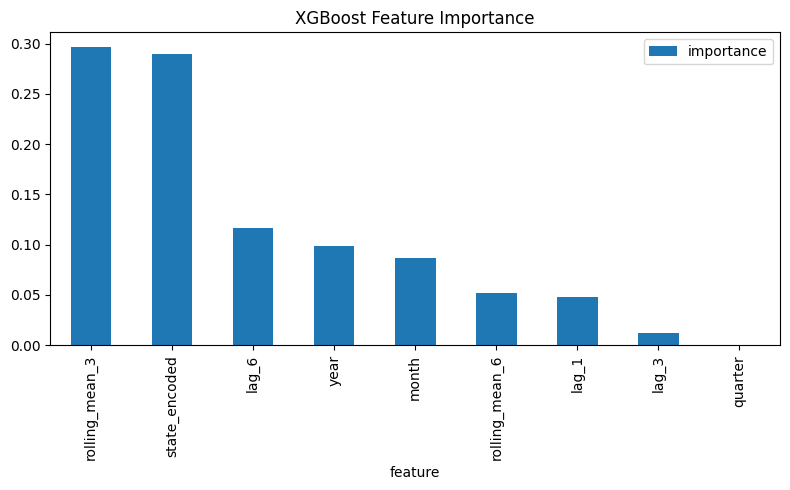

In [12]:
import matplotlib.pyplot as plt

importance_df.plot(
    x="feature",
    y="importance",
    kind="bar",
    figsize=(8,5)
)

plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

In [13]:
comparison = pd.DataFrame({
    "Model": ["ARIMA", "XGBoost"],
    "MAE": [246102.28, 8813.23],
    "RMSE": [327530.59, 16146.17],
    "MAPE": [2948.88, 2075.50]
})

comparison


,Model,MAE,RMSE,MAPE
0,ARIMA,246102.28,327530.59,2948.88
1,XGBoost,8813.23,16146.17,2075.50


In [14]:
comparison = pd.DataFrame({
    "model": ["ARIMA", "XGBoost"],
    "mae": [246102.28, 8813.23],
    "rmse": [327530.59, 16146.17],
    "mape": [2948.88, 2075.50]
})

comparison

,model,mae,rmse,mape
0,ARIMA,246102.28,327530.59,2948.88
1,XGBoost,8813.23,16146.17,2075.50


In [15]:
comparison.to_csv(
    "model_comparison.csv",
    index=False
)

In [16]:
importance_df.to_csv(
    "feature_importance.csv",
    index=False
)

In [17]:
import mlflow

print(mlflow.__version__)

3.14.0


In [18]:
import mlflow

mlflow.set_experiment("ServicePlus Forecasting")

2026/06/23 15:36:07 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/23 15:36:07 INFO mlflow.store.db.utils: Updating database tables
2026/06/23 15:36:08 INFO mlflow.tracking.fluent: Experiment with name 'ServicePlus Forecasting' does not exist. Creating a new experiment.


<Experiment: artifact_location='/Users/abhilashanegi/NIC_Forecasting/mlruns/1', creation_time=1782209168220, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1782209168220, lifecycle_stage='active', name='ServicePlus Forecasting', tags={}, trace_location=None, workspace='default'>

In [19]:
with mlflow.start_run(run_name="ARIMA"):

    mlflow.log_param("model", "ARIMA(1,1,1)")

    mlflow.log_metric("MAE", 246102.28)
    mlflow.log_metric("RMSE", 327530.59)
    mlflow.log_metric("MAPE", 2948.88)

In [20]:
with mlflow.start_run(run_name="XGBoost"):

    mlflow.log_param("model", "XGBoost")

    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("max_depth", 5)

    mlflow.log_metric("MAE", 8813.23)
    mlflow.log_metric("RMSE", 16146.17)
    mlflow.log_metric("MAPE", 2075.50)

In [22]:
mlflow.search_experiments()

[<Experiment: artifact_location='/Users/abhilashanegi/NIC_Forecasting/mlruns/1', creation_time=1782209168220, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1782209168220, lifecycle_stage='active', name='ServicePlus Forecasting', tags={}, trace_location=None, workspace='default'>,
 <Experiment: artifact_location='/Users/abhilashanegi/NIC_Forecasting/mlruns/0', creation_time=1782209168216, effective_trace_archival_retention=None, experiment_id='0', last_update_time=1782209168216, lifecycle_stage='active', name='Default', tags={}, trace_location=None, workspace='default'>]

In [23]:
import mlflow

mlflow.set_experiment("ServicePlus Forecasting")

<Experiment: artifact_location='/Users/abhilashanegi/NIC_Forecasting/mlruns/1', creation_time=1782209168220, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1782209168220, lifecycle_stage='active', name='ServicePlus Forecasting', tags={}, trace_location=None, workspace='default'>

In [24]:
with mlflow.start_run(run_name="ARIMA"):
    mlflow.log_param("model", "ARIMA(1,1,1)")
    mlflow.log_metric("MAE", 246102.28)
    mlflow.log_metric("RMSE", 327530.59)
    mlflow.log_metric("MAPE", 2948.88)

In [25]:
with mlflow.start_run(run_name="XGBoost"):
    mlflow.log_param("model", "XGBoost")
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("max_depth", 5)

    mlflow.log_metric("MAE", 8813.23)
    mlflow.log_metric("RMSE", 16146.17)
    mlflow.log_metric("MAPE", 2075.50)

In [26]:
import mlflow

exp = mlflow.get_experiment_by_name("ServicePlus Forecasting")
print(exp)

<Experiment: artifact_location='/Users/abhilashanegi/NIC_Forecasting/mlruns/1', creation_time=1782209168220, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1782209168220, lifecycle_stage='active', name='ServicePlus Forecasting', tags={}, trace_location=None, workspace='default'>


In [27]:
runs = mlflow.search_runs(
    experiment_names=["ServicePlus Forecasting"]
)

runs

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.RMSE,metrics.MAE,metrics.MAPE,params.learning_rate,params.model,params.max_depth,params.n_estimators,tags.mlflow.runName,tags.mlflow.source.type,tags.mlflow.user,tags.mlflow.source.name
0,14c080aa97074c429cf770ae5f36fe27,1,FINISHED,/Users/abhilashanegi/NIC_Forecasting/mlruns/1/...,2026-06-23 10:13:05.256000+00:00,2026-06-23 10:13:05.294000+00:00,16146.17,8813.23,2075.50,0.05,XGBoost,5,200,XGBoost,NOTEBOOK,abhilashanegi,forecast.ipynb
1,005a9d1e3da64cceb7afa5ed0d4da72f,1,FINISHED,/Users/abhilashanegi/NIC_Forecasting/mlruns/1/...,2026-06-23 10:12:58.324000+00:00,2026-06-23 10:12:58.354000+00:00,327530.59,246102.28,2948.88,NaN,"ARIMA(1,1,1)",NaN,NaN,ARIMA,NOTEBOOK,abhilashanegi,forecast.ipynb
2,73f89eb1138940e2ba18836004b3fab7,1,FINISHED,/Users/abhilashanegi/NIC_Forecasting/mlruns/1/...,2026-06-23 10:06:23.741000+00:00,2026-06-23 10:06:23.769000+00:00,16146.17,8813.23,2075.50,0.05,XGBoost,5,200,XGBoost,NOTEBOOK,abhilashanegi,forecast.ipynb
3,6a9e5ae8af4c4919ad434c9d690c0b16,1,FINISHED,/Users/abhilashanegi/NIC_Forecasting/mlruns/1/...,2026-06-23 10:06:14.780000+00:00,2026-06-23 10:06:14.803000+00:00,327530.59,246102.28,2948.88,NaN,"ARIMA(1,1,1)",NaN,NaN,ARIMA,NOTEBOOK,abhilashanegi,forecast.ipynb


In [28]:
%whos

Variable                         Type            Data/Info
----------------------------------------------------------
LabelEncoder                     type            <class 'sklearn.preproces<...>ing._label.LabelEncoder'>
X                                DataFrame       Shape: (130, 9)
XGBRegressor                     type            <class 'xgboost.sklearn.XGBRegressor'>
X_test                           DataFrame       Shape: (26, 9)
X_train                          DataFrame       Shape: (104, 9)
comparison                       DataFrame       Shape: (2, 4)
df                               DataFrame       Shape: (130, 12)
exp                              Experiment      <Experiment: artifact_loc<...>one, workspace='default'>
features                         list            n=9
importance_df                    DataFrame       Shape: (9, 2)
le                               LabelEncoder    LabelEncoder()
mae                              float           8813.232421875
mape             

In [29]:
comparison.to_csv("model_comparison.csv", index=False)

print("Saved model_comparison.csv")
comparison

Saved model_comparison.csv


,model,mae,rmse,mape
0,ARIMA,246102.28,327530.59,2948.88
1,XGBoost,8813.23,16146.17,2075.50


In [30]:
importance_df.to_csv("feature_importance.csv", index=False)

print("Saved feature_importance.csv")
importance_df

Saved feature_importance.csv


,feature,importance
6,rolling_mean_3,0.296490
8,state_encoded,0.290220
5,lag_6,0.116143
0,year,0.098240
1,month,0.086881
7,rolling_mean_6,0.051630
3,lag_1,0.048156
4,lag_3,0.012238
2,quarter,0.000000


In [31]:
import os

print(os.getcwd())

/Users/abhilashanegi/NIC_Forecasting


In [32]:
pd.read_csv("model_comparison.csv")

,model,mae,rmse,mape
0,ARIMA,246102.28,327530.59,2948.88
1,XGBoost,8813.23,16146.17,2075.50


In [33]:
pd.read_csv("feature_importance.csv")

,feature,importance
0,rolling_mean_3,0.296490
1,state_encoded,0.290220
2,lag_6,0.116143
3,year,0.098240
4,month,0.086881
5,rolling_mean_6,0.051630
6,lag_1,0.048156
7,lag_3,0.012238
8,quarter,0.000000


In [1]:
import os
import glob

# Search for any mention of LightGBM in all notebooks and Python files
for file in glob.glob("*.ipynb") + glob.glob("*.py"):
    print(f"\n----- {file} -----")
    with open(file, "r", encoding="utf-8", errors="ignore") as f:
        text = f.read()

    keywords = ["lightgbm", "LightGBM", "LGBMRegressor", "lightgbm.sklearn"]

    found = False
    for keyword in keywords:
        if keyword in text:
            print(f"✅ Found: {keyword}")
            found = True

    if not found:
        print("❌ No LightGBM references")


----- Untitled.ipynb -----
❌ No LightGBM references

----- forecasting.ipynb -----
❌ No LightGBM references

----- forecast.ipynb -----
✅ Found: lightgbm
✅ Found: LightGBM


In [2]:
import nbformat

nb = nbformat.read("forecast.ipynb", as_version=4)

for i, cell in enumerate(nb.cells):
    if cell.cell_type == "code":
        src = cell.source
        if "lightgbm" in src.lower() or "LGBMRegressor" in src:
            print(f"\n===== CELL {i} =====\n")
            print(src)


===== CELL 57 =====

!pip install lightgbm

===== CELL 58 =====

import lightgbm as lgb

print(lgb.__version__)

===== CELL 59 =====

import lightgbm as lgb

print(lgb.__version__)


In [3]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

lgb_model = LGBMRegressor(
    random_state=42,
    n_estimators=100,
    learning_rate=0.1
)

lgb_model.fit(X_train, y_train)

lgb_preds = lgb_model.predict(X_test)

lgb_mae = mean_absolute_error(y_test, lgb_preds)
lgb_rmse = np.sqrt(mean_squared_error(y_test, lgb_preds))
lgb_mape = mean_absolute_percentage_error(y_test, lgb_preds) * 100

print("LightGBM Results")
print("MAE :", lgb_mae)
print("RMSE:", lgb_rmse)
print("MAPE:", lgb_mape)

NameError: name 'X_train' is not defined

In [4]:
%whos

Variable                         Type             Data/Info
-----------------------------------------------------------
LGBMRegressor                    type             <class 'lightgbm.sklearn.LGBMRegressor'>
cell                             NotebookNode     {'cell_type': 'code', 'ex<...>tputs': [], 'source': ''}
f                                TextIOWrapper    <_io.TextIOWrapper name='<...>ode='r' encoding='utf-8'>
file                             str              forecast.ipynb
found                            bool             True
glob                             module           <module 'glob' from '/Lib<...>/lib/python3.13/glob.py'>
i                                int              95
keyword                          str              lightgbm.sklearn
keywords                         list             n=4
lgb_model                        LGBMRegressor    LGBMRegressor(random_state=42)
mean_absolute_error              function         <function mean_absolute_error at 0x115cf2200>


In [5]:
from sklearn.model_selection import train_test_split

In [6]:
%whos

Variable                         Type             Data/Info
-----------------------------------------------------------
LGBMRegressor                    type             <class 'lightgbm.sklearn.LGBMRegressor'>
cell                             NotebookNode     {'cell_type': 'code', 'ex<...>tputs': [], 'source': ''}
f                                TextIOWrapper    <_io.TextIOWrapper name='<...>ode='r' encoding='utf-8'>
file                             str              forecast.ipynb
found                            bool             True
glob                             module           <module 'glob' from '/Lib<...>/lib/python3.13/glob.py'>
i                                int              95
keyword                          str              lightgbm.sklearn
keywords                         list             n=4
lgb_model                        LGBMRegressor    LGBMRegressor(random_state=42)
mean_absolute_error              function         <function mean_absolute_error at 0x115cf2200>


In [7]:
%who

LGBMRegressor	 cell	 f	 file	 found	 glob	 i	 keyword	 keywords	 
lgb_model	 mean_absolute_error	 mean_absolute_percentage_error	 mean_squared_error	 nb	 nbformat	 np	 os	 src	 
text	 train_test_split	 


In [8]:
import nbformat

nb = nbformat.read("forecast.ipynb", as_version=4)

for i, cell in enumerate(nb.cells):
    if cell.cell_type == "code":
        if ("train_test_split(" in cell.source or
            "X_train" in cell.source or
            "y_train" in cell.source):
            print("="*80)
            print("CELL", i)
            print(cell.source)

CELL 56
split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

print("Train:", X_train.shape)
print("Test :", X_test.shape)
CELL 64
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)
CELL 69
features = [
    "year",
    "month",
    "quarter",
    "lag_1",
    "lag_3",
    "lag_6",
    "rolling_mean_3",
    "rolling_mean_6",
    "state_encoded"
]

X = df[features]
y = df["applications"]

split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

print(X_train.shape)
print(X_test.shape)
CELL 70
model.fit(X_train, y_train)
CELL 73
import pandas as pd

importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
})

importance_df = importance_

In [9]:
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": lgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

importance_df

NameError: name 'pd' is not defined

In [10]:
import pandas as pd

In [11]:
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": lgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

importance_df

NameError: name 'X_train' is not defined

In [12]:
%whos

Variable                         Type             Data/Info
-----------------------------------------------------------
LGBMRegressor                    type             <class 'lightgbm.sklearn.LGBMRegressor'>
cell                             NotebookNode     {'cell_type': 'code', 'ex<...>tputs': [], 'source': ''}
f                                TextIOWrapper    <_io.TextIOWrapper name='<...>ode='r' encoding='utf-8'>
file                             str              forecast.ipynb
found                            bool             True
glob                             module           <module 'glob' from '/Lib<...>/lib/python3.13/glob.py'>
i                                int              102
keyword                          str              lightgbm.sklearn
keywords                         list             n=4
lgb_model                        LGBMRegressor    LGBMRegressor(random_state=42)
mean_absolute_error              function         <function mean_absolute_error at 0x115cf2200>

In [13]:
import nbformat

nb = nbformat.read("forecast.ipynb", as_version=4)

for i, cell in enumerate(nb.cells):
    if cell.cell_type == "code":
        if "df =" in cell.source or "read_csv" in cell.source or "read_sql" in cell.source:
            print("="*80)
            print("CELL", i)
            print(cell.source)

CELL 2
import pandas as pd

df = pd.read_csv("/Users/abhilashanegi/Downloads/top_states_monthly.csv")
df.head()
CELL 10
import pandas as pd

forecast_df = pd.DataFrame({
    'month_start': [
        '2026-06-01',
        '2026-07-01',
        '2026-08-01',
        '2026-09-01',
        '2026-10-01',
        '2026-11-01'
    ],
    'forecast_applications': [
        371410.7986132679,
        352139.3425300732,
        342404.04783489153,
        337390.12961442844,
        334781.4834695042,
        333416.9896972891
    ]
})

forecast_df
CELL 12
heatmap_df = forecast_df.assign(key=1).merge(
    state_share.assign(key=1),
    on='key'
).drop('key', axis=1)

heatmap_df['forecast_applications'] = (
    heatmap_df['forecast_applications']
    * heatmap_df['share_pct'] / 100
)

heatmap_df = heatmap_df[[
    'month_start',
    'state',
    'forecast_applications'
]]

heatmap_df.head(20)
CELL 14
import pandas as pd

monthly = pd.read_sql("""
SELECT month,
       applications
FROM report_mont

In [14]:
import pandas as pd

df = pd.read_csv("/Users/abhilashanegi/Downloads/top_states_monthly.csv")

In [15]:
features = [
    "year",
    "month",
    "quarter",
    "lag_1",
    "lag_3",
    "lag_6",
    "rolling_mean_3",
    "rolling_mean_6",
    "state_encoded"
]

X = df[features]
y = df["applications"]

split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

KeyError: "None of [Index(['year', 'month', 'quarter', 'lag_1', 'lag_3', 'lag_6', 'rolling_mean_3',\n       'rolling_mean_6', 'state_encoded'],\n      dtype='object')] are in the [columns]"

In [16]:
print(df.columns.tolist())

['month_start', 'state', 'applications']


In [17]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("/Users/abhilashanegi/Downloads/top_states_monthly.csv")

df["month_start"] = pd.to_datetime(df["month_start"])

df["year"] = df["month_start"].dt.year
df["month"] = df["month_start"].dt.month
df["quarter"] = df["month_start"].dt.quarter

df = df.sort_values(["state", "month_start"]).reset_index(drop=True)

le = LabelEncoder()
df["state_encoded"] = le.fit_transform(df["state"])

df["lag_1"] = df.groupby("state")["applications"].shift(1)
df["lag_3"] = df.groupby("state")["applications"].shift(3)
df["lag_6"] = df.groupby("state")["applications"].shift(6)

df["rolling_mean_3"] = (
    df.groupby("state")["applications"]
      .transform(lambda x: x.shift(1).rolling(3).mean())
)

df["rolling_mean_6"] = (
    df.groupby("state")["applications"]
      .transform(lambda x: x.shift(1).rolling(6).mean())
)

df = df.dropna()

print(df.columns.tolist())
print(df.shape)

['month_start', 'state', 'applications', 'year', 'month', 'quarter', 'state_encoded', 'lag_1', 'lag_3', 'lag_6', 'rolling_mean_3', 'rolling_mean_6']
(130, 12)


In [18]:
features = [
    "year",
    "month",
    "quarter",
    "lag_1",
    "lag_3",
    "lag_6",
    "rolling_mean_3",
    "rolling_mean_6",
    "state_encoded"
]

X = df[features]
y = df["applications"]

split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (104, 9)
Test : (26, 9)


In [19]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

lgb_model = LGBMRegressor(
    random_state=42,
    n_estimators=100,
    learning_rate=0.1
)

lgb_model.fit(X_train, y_train)

lgb_preds = lgb_model.predict(X_test)

lgb_mae = mean_absolute_error(y_test, lgb_preds)
lgb_rmse = np.sqrt(mean_squared_error(y_test, lgb_preds))
lgb_mape = mean_absolute_percentage_error(y_test, lgb_preds) * 100

print("LightGBM Results")
print("MAE :", lgb_mae)
print("RMSE:", lgb_rmse)
print("MAPE:", lgb_mape)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000515 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 195
[LightGBM] [Info] Number of data points in the train set: 104, number of used features: 9
[LightGBM] [Info] Start training from score 12219.951923
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [20]:
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": lgb_model.feature_importances_
}).sort_values("importance", ascending=False)

importance_df

,feature,importance
1,month,53
3,lag_1,51
4,lag_3,46
6,rolling_mean_3,40
5,lag_6,33
7,rolling_mean_6,30
8,state_encoded,27
0,year,17
2,quarter,0


In [21]:
comparison

NameError: name 'comparison' is not defined

In [22]:
%whos

Variable                         Type             Data/Info
-----------------------------------------------------------
LGBMRegressor                    type             <class 'lightgbm.sklearn.LGBMRegressor'>
LabelEncoder                     type             <class 'sklearn.preproces<...>ing._label.LabelEncoder'>
X                                DataFrame        Shape: (130, 9)
X_test                           DataFrame        Shape: (26, 9)
X_train                          DataFrame        Shape: (104, 9)
cell                             NotebookNode     {'cell_type': 'code', 'ex<...>tputs': [], 'source': ''}
df                               DataFrame        Shape: (130, 12)
f                                TextIOWrapper    <_io.TextIOWrapper name='<...>ode='r' encoding='utf-8'>
features                         list             n=9
file                             str              forecast.ipynb
found                            bool             True
glob                             

In [23]:
pd.read_csv("model_comparison.csv")

,model,mae,rmse,mape
0,ARIMA,246102.28,327530.59,2948.88
1,XGBoost,8813.23,16146.17,2075.50


In [24]:
import os

os.listdir()

['model_comparison.csv',
 'Untitled.ipynb',
 'feature_importance.csv',
 'forecast_change_kpi.csv',
 'mlflow.db',
 'forecasting.ipynb',
 'top_states_forecast.csv',
 'forecast_confidence_intervals.csv',
 'forecast.ipynb',
 '.ipynb_checkpoints']

In [25]:
from xgboost import XGBRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)
import numpy as np

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_mape = mean_absolute_percentage_error(y_test, xgb_preds) * 100

print("XGBoost Results")
print("MAE :", xgb_mae)
print("RMSE:", xgb_rmse)
print("MAPE:", xgb_mape)

XGBoost Results
MAE : 8813.232421875
RMSE: 16146.169328977076
MAPE: 2075.5048751831055


In [26]:
importance_df.to_csv("lightgbm_feature_importance.csv", index=False)

In [27]:
comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Forecast": xgb_preds
})

comparison_df.to_csv("actual_vs_forecast.csv", index=False)